In [14]:
#from a fieldmap in straight coordinates to one in curved coordinates
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s
import pyvista as pv

(0.0, 1.0)

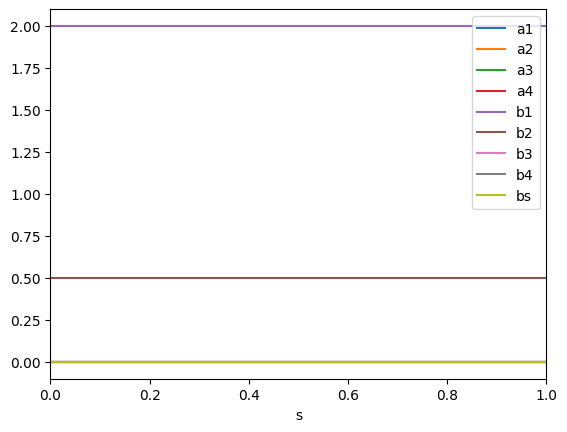

In [2]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [0, 0, 0, 0]
b_coeffs = [2,0.5,0, 0]
#get scalar potential
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
expansion.plot_components()
plt.xlabel('s')
plt.xlim((0,1))

Scalar potential phi(x,y,s): y*(3.0*x + 12)/6
Scalar potential phi at (0.4,0.2,0.5): 0.43999999999999995


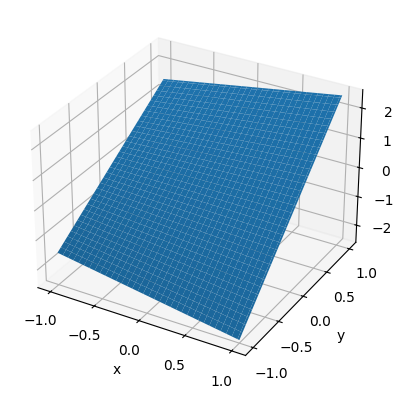

In [4]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define x,y,s axes to convert the symbolic expression of phi into a numerical array
xa= np.linspace(-1,1,101)
ya=np.linspace(-1,1,101)
sa=np.linspace(-1,1,101)
#make a 3d plot of phi as a function of x and y for a fixed s
X, Y = np.meshgrid(xa, ya)
P = phi_func(X, Y, 0.5)#s=0.5 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, P)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [5]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)
# Evaluate on grid
X,Y,S = np.meshgrid(xa, ya, sa)
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)
#print("Bx shape:", Bx_ana.shape, "By shape:", By_ana.shape, "Bs shape:", Bs_ana.shape)
# X, Y, S  from meshgrid in straight frame
# Bx_ana, By_ana, Bs_ana are the corresponding field arrays
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    Bx_ana.ravel(),
    By_ana.ravel(),
    Bs_ana.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)
#print(xa.shape)

Pass to curved coordinates

In [6]:
rho = .5
phi = 1.
xFS = np.linspace(-0.05, 0.05, 101)
yFS = np.linspace(-0.05, 0.05, 101)
sFS = np.linspace(-rho*phi, rho*phi, 103)
interp_rad=0.025
fm_fs = fm.calc_FS_coords(xFS, yFS, sFS, rho, phi, radius=interp_rad)

Now I can extract multipole coefficients using harmonic analysis

In [7]:
# Choose a fixed s value (s=0 is the magnet center)
s_fixed = 0.0

bnianHA=fm_fs.harmonic_analysis_at_s(spos=s_fixed,rmin=0.01,rmax=1.0 )
bnHA=bnianHA.real
print("recovered bn(0) in curved frame: ", bnHA)

recovered bn(0) in curved frame:  [2.53525215e+00 5.43396090e-01 3.40237563e+02 1.62423694e+03
 7.73678103e+03]


HA along s

In [8]:
svals, bnofs, errorbn = fm_fs.s_harmonics(order=4, rmin=0.002, rmax= 0.05, nr=40, radius=interp_rad)

In [44]:
def fieldmap_to_bent_cylindrical(
    fieldmap,
    rho,
    rmin=0.001,
    rmax=0.101,
    nr=128,
    ntheta=128,
    smin=-1.0,
    smax=1.0,
    ns=40,
    radius=0.02,
    theta_endpoint=False,
    coord_names=("X", "Y", "Z"),
    field_names=("Bx", "By", "Bs"),
):
    """
    Interpolate a fieldmap onto a bent cylindrical grid.

    Parameters
    ----------
    fieldmap : ndarray, shape (N, 6)
        Columns are [X, Y, Z, F1, F2, F3].
    rho : float
        Bending radius [m].
    rmin, rmax : float
        Minor-radius range [m].
    nr, ntheta, ns : int
        Number of points in r, theta, s.
    smin, smax : float
        Longitudinal arc-length range [m].
    radius : float
        Interpolation radius for PyVista.
    theta_endpoint : bool
        Whether theta includes 2*pi.
    coord_names : tuple[str, str, str]
        Only documentary here.
    field_names : tuple[str, str, str]
        Names of the 3 field columns.

    Returns
    -------
    r_1d, theta_1d, s_1d : 1D arrays
    X, Y, Z : 3D arrays, shape (nr, ntheta, ns)
    fields : dict[str, ndarray]
        Sampled fields reshaped on the bent grid.
    dst : pyvista.StructuredGrid
        Interpolated bent grid.
    """
    fieldmap = np.asarray(fieldmap)
    if fieldmap.ndim != 2 or fieldmap.shape[1] < 6:
        raise ValueError("fieldmap must have shape (N, 6) or more")

    # source point cloud
    pts = fieldmap[:, :3]
    src = pv.PolyData(pts)

    for i, name in enumerate(field_names):
        src.point_data[name] = fieldmap[:, 3 + i]

    # bent cylindrical target grid
    r_1d = np.linspace(rmin, rmax, nr)
    theta_1d = np.linspace(0.0, 2.0*np.pi, ntheta, endpoint=theta_endpoint)
    s_1d = np.linspace(smin, smax, ns)

    R, TH, S = np.meshgrid(r_1d, theta_1d, s_1d, indexing="ij")
    PHI = S / rho

    # Convention: X radial offset, Y short transverse, Z long axis
    X = (rho + R*np.cos(TH)) * np.cos(PHI)
    Y = R*np.sin(TH)
    Z = (rho + R*np.cos(TH)) * np.sin(PHI)

    dst = pv.StructuredGrid(X, Y, Z)

    dst = dst.interpolate(
        src,
        radius=radius,
        sharpness=2.0,
        strategy="null_value",
        null_value=np.nan,
    )
    for name in field_names:
        frac = np.isfinite(dst.point_data[name]).sum() / dst.n_points
        print(f"{name} finite fraction = {frac:.4f}")
    fields = {}
    for name in field_names:
        arr = np.asarray(dst.point_data[name])
        fields[name] = arr.reshape(X.shape, order="F")

    return r_1d, theta_1d, s_1d, X, Y, Z, fields, dst

In [ ]:
nk=4
nl=nk//2+1
rmin=xFS[len(xFS)//2+1]
rmax=xFS[-1]
print(rmin, rmax)
thetahalf = phi/2
smax=rho*thetahalf
print(f"Calculated smax: {smax:.3f} m")
print("thetahalf (degrees):", np.degrees(thetahalf))
datafs=fm_fs.get_data()
print(datafs.shape, datafs[0:5])
r_1d, theta_1d, s_1d, X, Y, Z, fields, dst = fieldmap_to_bent_cylindrical(
    fieldmap=datafs,
    rho=rho,
    rmin=rmin,
    rmax=rmax,
    nr=128,
    ntheta=128,
    smin=-smax,
    smax=smax,
    ns=40,
    radius=0.8,
    field_names=["Bx", "By", "Bs"],
)
#print("r_1d:", r_1d[0:5])
print(fields['By'][0:5])
ByiBx_rts = fields["By"] + 1j*fields["Bx"]#shape (nr, ntheta, ns)
print(ByiBx_rts[0:5])

In [9]:
#with new HA method:
def dkongrid(Byibx_rts, rr, nk, s_index):
    """
    Takes a precomputed field array and computes d_k as a function of r 
    Parameters
    ----------
    Byibx_rts : complex array, shape (nr, ntheta, ns) representing (By + i*Bx) already evaluated on the (r, theta, s) grid.
    Theta samples must be uniform in [0, 2*pi).
    rr     : array of r values, shape (nr,)
    nk     : max |k|
    s_index: index along the s-axis to use

    Returns
    -------
    out : complex array, shape (nr, 2*nk+1)  — same as dkharmonics
    """
    ntheta = Byibx_rts.shape[1]

    b = Byibx_rts[:, :, s_index]        # (nr, ntheta) at specified s
    d = np.fft.fft(b, axis=1) / ntheta       # FFT along theta axis

    out = np.empty((len(rr), 2*nk+1), dtype=complex)
    out[:, 0]    = d[:, 0]
    out[:, 1::2] = d[:, 1 : nk+1]
    out[:, 2::2] = d[:, ntheta : ntheta-nk-1 : -1]

    return out
def dklfitraw_nodiv_cheb(dkofrarray, rr, nk, nl):
    '''
    Numerically stable version of dklfitraw_nodiv.
    Fits dk(r) = sum_l d_kl * r^(|k|+2l) directly (no division by r^k),
    using rn = rr/rr.max() to keep basis values in (0,1].
    
    The d_kl returned are in the original (unnormalized) r basis, i.e. the r0 scaling is absorbed back into the coefficients.
    '''
    r0 = rr.max()
    rn = rr / r0    # in (0, 1]
    dkl_norm = np.zeros((2*nk+1, nl), dtype=complex)

    # k=0: basis is rn^0, rn^2, rn^4, ...
    V0 = np.column_stack([rn**(2*l) for l in range(nl)])
    dkl_norm[0, :] = np.linalg.lstsq(V0, dkofrarray[:, 0], rcond=None)[0]

    for ik, k in enumerate(np.arange(1, nk+1)):
        V = np.column_stack([rn**(k + 2*l) for l in range(nl)])
        dkl_norm[2*ik+1, :] = np.linalg.lstsq(V, dkofrarray[:, 2*ik+1], rcond=None)[0]
        dkl_norm[2*ik+2, :] = np.linalg.lstsq(V, dkofrarray[:, 2*ik+2], rcond=None)[0]

    # Rescale: since rn = r/r0, rn^(k+2l) = r^(k+2l) / r0^(k+2l)
    # so d_kl_norm = d_kl * r0^(k+2l) → d_kl = d_kl_norm / r0^(k+2l)
    dkl = np.zeros((2*nk+1, nl), dtype=complex)
    dkl[0, :] = dkl_norm[0, :] / r0**(2*np.arange(nl))

    for ik, k in enumerate(np.arange(1, nk+1)):
        scale = r0**(k + 2*np.arange(nl))
        dkl[2*ik+1, :] = dkl_norm[2*ik+1, :] / scale
        dkl[2*ik+2, :] = dkl_norm[2*ik+2, :] / scale

    return dkl
#now let's recover the a,b coefficients
def bnianHAopt(dkl, nl, nk):#from dkl to bn and an
    # Precompute factorials
    fact = np.array([factorial(n) for n in range(nk)], dtype=np.int16)

    # Build k index dict mapping: row index for k = 0,1,-1,2,-2,...
    k_index = {0: 0}
    for i in range(1, nk+1):
        k_index[i]  = 2*i - 1
        k_index[-i] = 2*i #negative k gets even row

    result = np.zeros(nk, dtype=np.complex128)

    for n in range(nk):
        s = 0.0 + 0.0j #initialize sum
        max_l = min(n//2, nl-1)

        for l in range(max_l + 1):#
            k = n - 2*l
            if k == 0:
                s += dkl[k_index[0], l]
            else:
                s += dkl[k_index[k], l] + dkl[k_index[-k], l]

        result[n] = fact[n] * s

    return result
def LHongrid_nodiv_cheb(ByiBxongrid, s_index, nk):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkongrid(Byibx_rts=ByiBxongrid, rr=rr, nk=nk, s_index=s_index)
    dkl=dklfitraw_nodiv_cheb(dkofrarray=dk,rr=rr,nk=nk, nl=nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn


In [ ]:

dk = dkongrid(Byibx_rts=ByiBx_rts, rr=r_1d, nk=nk, s_index=s_1d.size // 2)
dkl = dklfitraw_nodiv_cheb(dkofrarray=dk, rr=r_1d, nk=nk, nl=nl)
print(dkl)
an, bn = bnianHAopt(dkl, nl, nk).imag, bnianHAopt(dkl, nl, nk).real
print("an:", an)
print("bn:", bn)

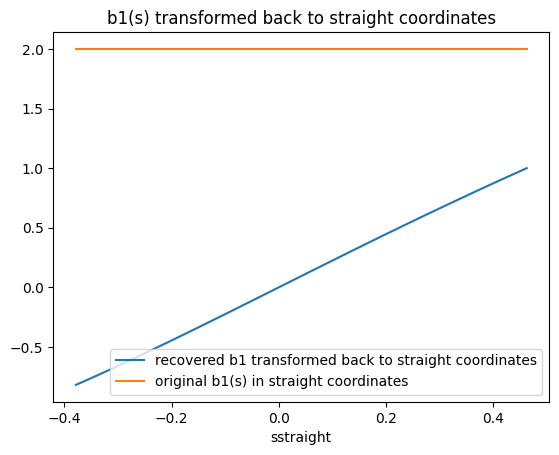

In [10]:
#convert results of HA to straight frame 
thetaE=0.
xx=np.linspace(-0.05,0.05, 103)#to match dimension of svals
sstraight = rho*np.sin(thetaE)-(rho+xx)*np.sin(thetaE- sFS/rho)#?
b1straight = bnofs[:,0]*rho*(thetaE-np.arctan(np.tan(thetaE-sstraight/rho/np.cos(thetaE)))) + bnofs[:,1]*(rho*(thetaE-np.arctan(np.tan(thetaE-sstraight/rho/np.cos(thetaE))))*(np.sqrt(rho**2 -2*rho*np.sin(thetaE)*sstraight*sstraight**2)-rho))
plt.plot(sstraight, b1straight, label='recovered b1 transformed back to straight coordinates')
plt.xlabel('sstraight')
plt.title('b1(s) transformed back to straight coordinates')
plt.plot(sstraight, np.ones_like(bnofs[:,0])*b_coeffs[0], label='original b1(s) in straight coordinates')
plt.legend()
plt.show()